In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from core.dgp import SkewTInnov,StudentTInnov

import matplotlib.pyplot as plt


In [20]:
import numpy as np
from scipy.special import gamma
from scipy.optimize import least_squares

# -----------------------------
# Hansen skew-t moments
# -----------------------------

def hansen_moments(nu, eta):
    """
    Calcula la asimetría (skewness) y curtosis (kurtosis) teóricas 
    de la distribución Skew-t de Hansen.
    """
    # La curtosis requiere nu > 4 para existir
    if nu <= 4:
        return np.nan, np.nan
        
    c = gamma((nu + 1) / 2) / (np.sqrt(np.pi * (nu - 2)) * gamma(nu / 2))
    
    # 1. Momentos Crudos (Raw moments: m1, m2, m3, m4)
    m1 = 4 * eta * c * (nu - 2) / (nu - 1)
    m2 = 1 + 3 * eta**2
    m3 = 16 * c * eta * (1 + eta**2) * ((nu - 2)**2) / ((nu - 1) * (nu - 3))
    m4 = 3 * (nu - 2) / (nu - 4) * (1 + 10 * eta**2 + 5 * eta**4)
    
    # 2. Momentos Centrales (Central moments: mu2, mu3, mu4)
    mu2 = m2 - m1**2
    if mu2 <= 0:
        return np.nan, np.nan
        
    mu3 = m3 - 3 * m1 * m2 + 2 * m1**3
    mu4 = m4 - 4 * m1 * m3 + 6 * m1**2 * m2 - 3 * m1**4
    
    # 3. Momentos Estandarizados
    skewness = mu3 / (mu2**1.5)
    kurtosis = mu4 / (mu2**2)
    
    return skewness, kurtosis

# -----------------------------
# Residuals (con penalización)
# -----------------------------

def residuals(x, skew_target, kurt_target):
    nu, eta = x
    
    s, k = hansen_moments(nu, eta)
    
    if np.isnan(s) or np.isnan(k):
        return [1e6, 1e6]  # penalización fuerte
    
    return [
        s - skew_target,
        k - kurt_target
    ]

# -----------------------------
# Calibración robusta
# -----------------------------

def calibrate(skew_target, kurt_target, n_starts=20):
    best_sol = None
    best_err = np.inf
    
    # bounds: IMPORTANTES (nu > 4 para curtosis, eta entre -1 y 1)
    bounds_lower = [4.01, -0.99]
    bounds_upper = [100.0, 0.99]
    
    for _ in range(n_starts):
        # inicialización aleatoria
        nu0 = np.random.uniform(5, 30)
        eta0 = np.random.uniform(-0.5, 0.5)
        
        try:
            res = least_squares(
                residuals,
                x0=[nu0, eta0],
                bounds=(bounds_lower, bounds_upper),
                args=(skew_target, kurt_target),
                method='trf',
                ftol=1e-10,
                xtol=1e-10
            )
            
            err = np.sum(res.fun**2)
            
            if err < best_err and res.success:
                best_err = err
                best_sol = res.x
                
        except:
            continue
            
    if best_sol is None:
        raise RuntimeError("No convergence in any start")
        
    # Calcular momentos finales logrados
    final_s, final_k = hansen_moments(best_sol[0], best_sol[1])
        
    return {
        "nu": best_sol[0],
        "eta": best_sol[1],
        "error_minimo": best_err,
        "skewness_logrado": final_s,
        "kurtosis_lograda": final_k
    }

# -----------------------------
# Ejemplo
# -----------------------------

skew_target = -1.88
kurt_target = 5.191

params = calibrate(skew_target, kurt_target, n_starts=500)

print(f"Nu estimado: {params['nu']:.4f}")
print(f"Eta estimado: {params['eta']:.4f}")
print(f"Skewness logrado: {params['skewness_logrado']:.4f} (Target: {skew_target})")
print(f"Kurtosis lograda: {params['kurtosis_lograda']:.4f} (Target: {kurt_target})")
print(f"Error (Suma de cuadrados): {params['error_minimo']:.4e}")

Nu estimado: 14.5031
Eta estimado: -0.9900
Skewness logrado: -1.2809 (Target: -1.88)
Kurtosis lograda: 5.2929 (Target: 5.191)
Error (Suma de cuadrados): 3.6932e-01


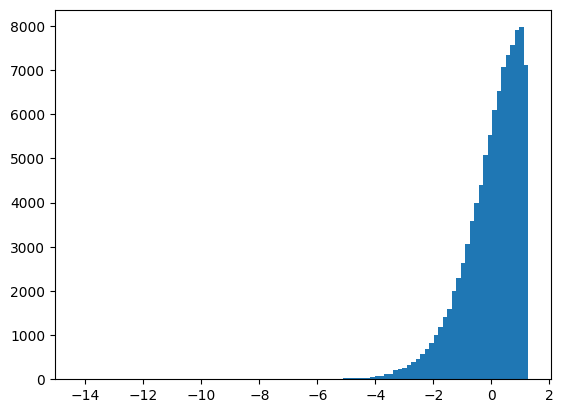

In [15]:
m = SkewTInnov(df=14.503, eta=-0.99, mean=0).calibrate_params(0.0,1.0)
rng = np.random.default_rng(41)
sample = m(100000, rng)
plt.hist(sample,bins=100);

In [16]:
sample.mean(), sample.std()

(np.float64(-0.0008725139914795199), np.float64(0.9989205978213918))

In [17]:
stats.kurtosis(sample, fisher=True),stats.skew(sample)

(np.float64(2.5209440645731247), np.float64(-1.2948154808577377))

In [18]:
m.calculate_theo_moments()
m.get_theo_moments()

{'skew': np.float64(-1.2808883067683166),
 'exc_kurt': np.float64(2.292885593585625),
 'rho': 0.0,
 'nu': 14.503,
 'mean': 0.0,
 'sigma': 1.0}

In [37]:
from arch.univariate import (
    ARX,
    ConstantMean,
    ConstantVariance,
    GARCH,
    GeneralizedError,
    Normal,
    SkewStudent,
    StudentsT,
)

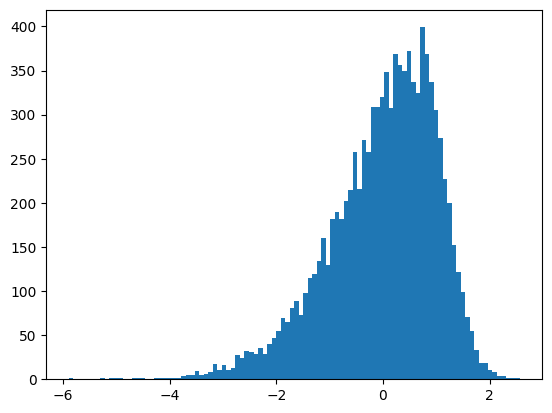

In [26]:
from arch.univariate import ConstantMean, ConstantVariance, SkewStudent

model = ConstantMean()
model.volatility = ConstantVariance()
model.distribution = SkewStudent()

params = np.array([0.0, 1, 30, -0.5])

sim = model.simulate(params, 10000)

y = sim['data']
plt.hist(y,bins=100);


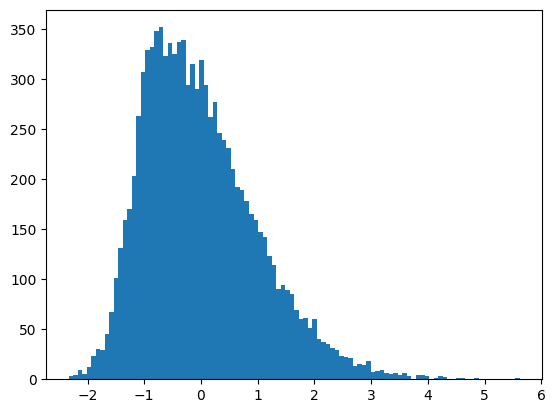

In [43]:
rng = np.random.default_rng(42)
aux = SkewStudent(seed=rng)
y = aux.simulate([50, 0.5])(10000)
plt.hist(y,bins=100); 

In [44]:
stats.kurtosis(y),stats.skew(y)

(np.float64(0.7334457425793381), np.float64(0.7928602519578309))

In [ ]:
from arch import arch_model

arch_model(None,mean='constant',vol='constant', dist='skewt')

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, kpss, acf



In [36]:
rng = np.random.default_rng(43)
x = rng.normal(0.05, 1.0, 500)
lb = acorr_ljungbox(x, lags=[1], return_df=True)

In [37]:
lb

,lb_stat,lb_pvalue
1,2.072323,0.149993


In [40]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox

rng = np.random.default_rng(42)

count = 0
N = 1000

for _ in range(N):
    x = rng.normal(0.05, 1.0, 5000)
    pval = acorr_ljungbox(x, lags=10, return_df=True)['lb_pvalue'].iloc[-1]
    if pval < 0.05:
        count += 1

print(count / N)

0.061


In [1]:
from core.dgp import GARCHProcess
import numpy as np

In [2]:
m = GARCHProcess()
rng = np.random.default_rng()
sample = m.simulate(1000, rng)

In [ ]:
import numpy as np
from scipy import stats
from arch.univariate import ConstantMean, Normal
from arch.univariate import GARCH

class GARCH11FourthMoment(GARCH):
    def constraints(self) -> tuple[np.ndarray, np.ndarray]:
        # For GARCH(1,1), parameters are strictly: [omega, alpha, beta]
        # We need 4 rows for 4 constraints, and 3 columns for 3 parameters.
        a = np.zeros((4, 3))
        
        # 1. omega >= 0
        a[0, 0] = 1.0
        # 2. alpha >= 0
        a[1, 1] = 1.0
        # 3. beta >= 0
        a[2, 2] = 1.0
        
        # 4. 4th moment linear guarantee: sqrt(3)*alpha + beta <= 1
        # To format as Ax >= b, we multiply by -1: -sqrt(3)*alpha - beta >= -1
        a[3, 1] = -np.sqrt(3)
        a[3, 2] = -1.0
        
        b = np.zeros(4)
        b[3] = -1.0
        
        return a, b

class YourModelClass:
    def fit(self, x):
        # 1. Construct the model manually using your custom volatility class
        am = ConstantMean(x)
        am.volatility = GARCH11FourthMoment(p=1, q=1)
        am.distribution = Normal()
        
        # 2. Fit the model
        res_fit = am.fit(update_freq=0, disp=False)
        
        # 3. Return the extracted parameters
        return {
            "omega": res_fit.params['omega'], 
            "alpha": res_fit.params['alpha[1]'], 
            "beta": res_fit.params['beta[1]'], 
            "skew": float(stats.skew(x)), 
            "exc_kurt": float(stats.kurtosis(x, fisher=True))
        }

In [6]:
aux = YourModelClass()
aux.fit(sample)

{'omega': np.float64(0.05163010915517617),
 'alpha': np.float64(0.07838210616408382),
 'beta': np.float64(0.8628316833327622),
 'skew': 0.1017530813771638,
 'exc_kurt': 0.3884430213929888}

In [4]:
import numpy as np
import pandas as pd
from scipy import stats

from core.dgp import SkewTInnov,StudentTInnov

import matplotlib.pyplot as plt


from arch import arch_model
from arch.univariate import ConstantMean, GARCH, ARX
from arch.univariate.distribution import (
    Normal,
    StudentsT,
    SkewStudent,
)

In [5]:
df= 80
eta = -0

In [6]:
sample =  SkewStudent(seed=42).simulate([df, eta])(1000000)

In [7]:
stats.skew(sample), stats.kurtosis(sample)

(np.float64(0.0007541143817929793), np.float64(0.08260649231313266))

In [8]:
SkewStudent(seed=42).moment(3, [df, eta])

np.float64(0.0)

In [9]:
SkewStudent(seed=42).moment(4, [df, eta]) -3 

np.float64(0.07894736842102867)

In [1]:
import numpy as np
from scipy import stats

In [2]:
from pathlib import Path

from config import RESULTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [50]:
df= 80
eta = -0.0

In [4]:
from core.dgp import DGP_EXAMPLES, GARCHProcess


DGP_EXAMPLES["garch_skew"]=lambda: GARCHProcess(dist="skewt", dist_params=[df, eta]).calibrate_params(mu=0.05, sigma=2)
#DGP_EXAMPLES["garch_t"]=lambda: GARCHProcess(dist="t", dist_params=[df]).calibrate_params(mu=0.0, sigma=1)


In [46]:
GARCHProcess(dist="skewt", dist_params=[df, eta]).calibrate_params(mu=0.05, sigma=1)

GARCHProcess(omega=0.050000000000000044, alpha=0.1, beta=0.85, dist='skewt', dist_params=[20, -0.0])

In [51]:
process = GARCHProcess(dist="t", dist_params=[df]).calibrate_params(mu=0.5, sigma=2)
process.get_theo_moments()

{'skew': 0.0,
 'exc_kurt': 0.9133790737564316,
 'rho': 0.0,
 'nu': 80,
 'mean': 0.5,
 'sigma': np.float64(2.0)}

In [52]:
sample = process.simulate(1000000, 43)

In [83]:
stats.skew(sample), stats.kurtosis(sample)

(np.float64(0.004165873424919658), np.float64(3.9682081874988286))

In [84]:
np.mean(sample), np.std(sample)

(np.float64(0.5022368905440605), np.float64(2.0185104480858076))

In [ ]:
def estimate_tail_index(y, tail='both', frac=0.05):
    """
    Estimate the tail index of a return series using the Hill estimator.

    Parameters:
        y (pd.Series): The series of returns.
        tail (str): 'left' for negative tail, 'right' for positive tail, 'both' for both tails.
        frac (float): Fraction of extreme values to use (e.g., 0.05 for 5%).

    Returns:
        dict: Tail indices for the selected tails.
    """

    y = y[ np.isfinite(y) ]
    n = len(y)
    k = int(frac * n)

    result = {}

    if tail in ['left', 'both']:
        neg_returns_sorted = np.sort(-y)  # left tail
        if k > 0 and len(neg_returns_sorted) >= k:
            top_k = neg_returns_sorted[:k]
            x_min = top_k[-1]
            hill = np.mean(np.log(top_k / x_min))
            result['left'] = 1 / hill if hill != 0 else np.nan
        else:
            result['left'] = np.nan

    if tail in ['right', 'both']:
        pos_returns_sorted = np.sort(y)[::-1]  # right tail
        if k > 0 and len(pos_returns_sorted) >= k:
            top_k = pos_returns_sorted[:k]
            x_min = top_k[-1]
            hill = np.mean(np.log(top_k / x_min))
            result['right'] = 1 / hill if hill != 0 else np.nan
        else:
            result['right'] = np.nan

    return result

In [53]:
estimate_tail_index(sample-np.mean(sample))

{'left': np.float64(3.9262182642847216),
 'right': np.float64(3.9262182642847216)}

In [26]:
# name : (dgp_names, model_short_names)
scenarios = {
    "aux": (
        ["garch_skew"],
        ["garch11"],
    ),
}

parameters = {
    "n_sim": [1_000, 10_000, 30_000, 100_000],
    "T":     [1000, 3000, 10000],
}

In [29]:
N_SIM  = 30_000
N_JOBS = 8
param_name = "n_sim"
param_values = parameters[param_name]

experiments = {
    "aux": ExperimentSpec(
        scenario   = scenarios["aux"],
        param_name = param_name,
        param_values = param_values,
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        T_default  = 500,
        sr_default  = 0.5,
        n_jobs = N_JOBS,
        th_moments = True,
    ),
}

In [30]:
run_selected_configs(
    experiments,
    selected_experiments=[
        "aux",
    ],
)


  Experiment: aux
  [1/4]  n_sim=1000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/4]  n_sim=10000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/4]  n_sim=30000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [4/4]  n_sim=100000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE


In [31]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,
                       log=True,
                       xticks=param_values, markers=['o', 'X'])

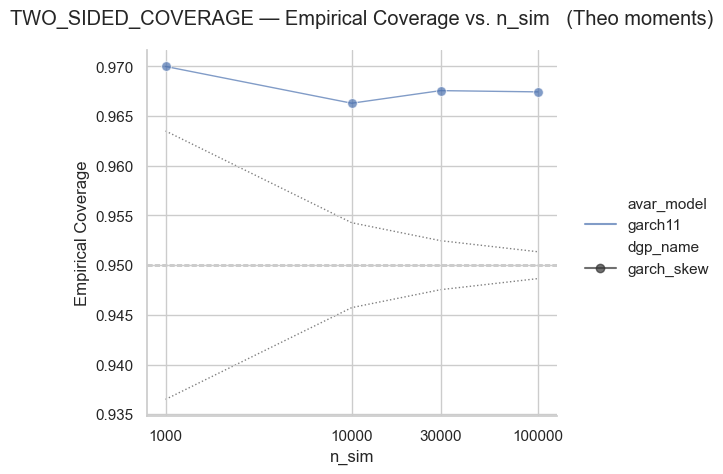

In [32]:
run_analysis(experiments, "aux", alpha=0.05, plot_mask=[0,0,1],
             line_plot_kargs=line_plot_kargs)

In [1]:
from core.dgp import DGP_EXAMPLES, ARGARCHProcess

import numpy as np
from scipy import stats

In [2]:
m = ARGARCHProcess(phi=0.3).calibrate_params(0.15, 0.3)

In [3]:
m.get_theo_moments()

{'skew': 0,
 'exc_kurt': 0,
 'rho': 0.3001593223304086,
 'nu': 0,
 'mean': np.float64(0.1502028943415486),
 'sigma': np.float64(0.2997811624537779)}

In [ ]:
m.th_mean

0.3001593223304086

In [1]:
import numpy as np

def k_u(k_ep, alpha, beta):
    num = 1 - (alpha + beta)**2
    den = 1 - (alpha + beta)**2 - alpha**2 * (k_ep - 1)
    return k_ep * num / den

def k_r_from_k_ep(k_ep, phi, alpha, beta):
    ku = k_u(k_ep, alpha, beta)
    
    term1 = 1 / (1 - phi**2 * (alpha + beta))
    
    inner = (1 - alpha - beta) / (1 - phi**2) + (beta / k_ep + alpha) * ku
    
    big = 6 * phi**2 * (term1 * (1 - phi**2)**2 * inner) + ku * (1 - phi**2)**2
    
    return big / (1 - phi**4)

In [10]:
from scipy.optimize import root_scalar

def invert_k_r(k_r_target, phi, alpha, beta, bracket=(1e-6, 15)):
    
    def objective(k_ep):
        return k_r_from_k_ep(k_ep, phi, alpha, beta) - k_r_target
    
    sol = root_scalar(objective, bracket=bracket, method='brentq')
    
    if not sol.converged:
        raise ValueError("No convergió")
    
    return sol.root

In [ ]:
# parámetros ejemplo
phi = 0.5
alpha = 0.1
beta = 0.8

k_ep_true = 4

# forward
k_r_val = k_r_from_k_ep(k_ep_true, phi, alpha, beta)

# invert
k_ep_est = invert_k_r(k_r_val, phi, alpha, beta)

print(k_ep_true, k_ep_est)

<built-in function print>
4 4.0


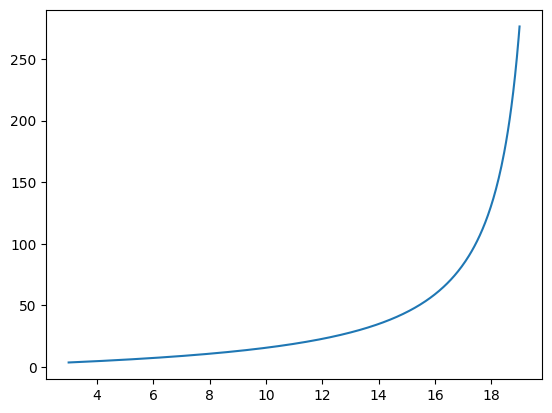

In [13]:
import matplotlib.pyplot as plt

k_vals = np.linspace(3, 19, 500)
r_vals = [k_r_from_k_ep(k, phi, alpha, beta) for k in k_vals]

plt.plot(k_vals, r_vals)

plt.show()

In [10]:
import numpy as np
from arch import arch_model
from core.dgp import ARGARCHProcess

In [11]:
m = ARGARCHProcess(phi=0.3)
x = m.simulate(1000000, 42)

In [12]:
am = arch_model(x, mean='ARX', lags=1, vol='GARCH',p=1,q=1, dist='normal', rescale=True)
res_fit = am.fit(update_freq=0,disp=False)

In [13]:
res_fit.params

Const      -0.000448
y[1]        0.300146
omega       0.051492
alpha[1]    0.101268
beta[1]     0.847355
Name: params, dtype: float64

In [7]:
res_fit.params

Const       1.835391
y[1]       -0.546979
omega       0.036010
alpha[1]    0.000000
beta[1]     0.975903
Name: params, dtype: float64

In [5]:
def _avar(sr, rho=0.2, omega=0.05, alpha=0.08, beta=0.87, exc_kurt=0, **kw):

    D1 = 1 - 2 * alpha * beta - beta**2
    D3 = 1 - rho**2 * (alpha + beta)
    N1 = 1 - alpha * beta - beta**2

    # A expandido
    A = (6 * rho**2 * alpha * N1) / (D3 * D1)

    # Términos principales
    phi=rho
    term1 = (1 + phi) / (1 - phi)
    k_r = exc_kurt + 3

    var_a = 4 * phi**2 * (1-phi**2)**2 / (1-phi**2) * ((1/(1+A)*((1+phi**2)*k_r - 5*phi**2 - 1))*alpha*(N1)/(D1)/(D3) + 1 )
    var_eta = (1-phi**2)**2 * (1/(1+A)) / (1-phi**2) * ( (1+phi**2)*k_r - 5*phi**2 - 1 ) * (1-(alpha+beta)**2)/(D1) 

    S_22 = 1/(1-phi**2)**2 * (var_a + ((1-beta)/(1-alpha-beta))**2 * var_eta) 
    term2 = 0.25 * sr**2 * S_22

    return term1 + term2

In [7]:
def calcular_S_vv(phi, sr, alpha, beta, exc_kurt):
    # 1. Calcular el bloque K
    k_r = exc_kurt + 3
    phi2 = phi**2
    den_comun = 1 - 2*alpha*beta - beta**2
    
    # 1. Bloque K
    K = (1 + phi2) * k_r - 5 * phi2 - 1
    
    # 2. Bloque A
    num_A = 1 - alpha*beta - beta**2
    factor_A = 1 - phi2 * (alpha + beta)
    A = 6 * phi2 * alpha * (num_A / den_comun) * (1 / factor_A)
    
    # 3. Fracción de parámetros (ahora sin el término 1/(1-phi2))
    num_params = ((1 - beta)**2) * (1 + alpha + beta)
    den_params = (1 - alpha - beta) * den_comun
    fraccion_params = num_params / den_params
    
    # 4. Cálculo final de S_vv
    termino_interactivo = (2/3) * A + fraccion_params
    S_vv = (1 / (1 - phi2)) * (4 * phi2 + (K / (1 + A)) * termino_interactivo)

    term2 = 0.25 * sr**2 * S_vv
    term1 = (1 + phi) / (1 - phi)
    return term1 + term2


In [9]:
calcular_S_vv(0.3, 0.5, 0.08, 0.87, 7)

5.729710632943522

In [10]:
_avar(0.5, rho=0.3, omega=0.05, alpha=0.08, beta=0.87, exc_kurt=7)

5.729710632943521

  PSR (iid Normal) vs PSR (iid General) vs Adjusted SR — T=50, SR*=0.1
 Portfolio      SR    Skew     Kurt   PSR_norm   PSR_gen     Gap   Adj_SR
--------------------------------------------------------------------------------------------------------------
        P1  0.2000   -1.17     4.37     0.7559    0.7329  +0.0230   0.1917
        P2  0.2000   -0.17     2.57     0.7559    0.7528  +0.0030   0.1990
        P3  0.1980   -2.39    13.40     0.7515    0.7066  +0.0450   0.1790
        P4  0.1980   -0.03     2.57     0.7515    0.7515  +0.0001   0.1980
        P5  0.1950   -1.58     5.14     0.7450    0.7166  +0.0284   0.1843
        P6  0.1950   -0.12     2.29     0.7450    0.7433  +0.0017   0.1945
        P7  0.1920   -2.09     7.71     0.7383    0.7028  +0.0355   0.1778
        P8  0.1920   -0.23     3.11     0.7383    0.7339  +0.0044   0.1906
--------------------------------------------------------------------------------------------------------------
  Gap = PSR_norm − PSR_gen  (posi

In [ ]:
"""
Sharpe Ratio AVar Sensitivity Analysis Framework
================================================

A function-agnostic framework for sensitivity analysis of the asymptotic
variance (AVar) of Sharpe ratio estimators.

Design goals
------------
1. Accept ANY ``avar(**params) -> float`` function plus an OPTIONAL list of
   parameter specs. If specs are missing they are inferred from the signature.
2. Handle BOTH individual constraints (e.g. ``alpha in (0,1)``) and joint
   constraints (e.g. GARCH stationarity ``alpha + beta < 1``, fourth-moment
   existence ``kappa_z * alpha^2 + 2*alpha*beta + beta^2 < 1``).
3. Be modular: ``LocalSensitivity``, ``OATSensitivity``, ``JointSensitivity``
   and ``GlobalSensitivity`` are independently usable; ``AVarSensitivityFramework``
   is a thin facade for one-shot reports.
4. Be creative: persistence paths, boundary-distance maps, Sobol indices with
   rejection sampling, iso-AVar contour finding, worst-case search.

The framework is independent of any specific AVar formula; the two functions
in the docstring at the bottom are illustrative only.
"""
from __future__ import annotations

import inspect
import warnings
from dataclasses import dataclass, field
from typing import Any, Callable, Mapping, Optional, Sequence

import numpy as np
import pandas as pd


# ============================================================================
# 1. CORE DATA MODEL
# ============================================================================

@dataclass(frozen=True)
class Parameter:
    """Specification for a single model parameter.

    Attributes
    ----------
    name : str
        Must match the kwarg name in the avar function.
    default : float
        Default / base value used when not being swept.
    bounds : tuple of (float, float)
        (low, high) used for sampling and sweeps. These are *individual*
        bounds; joint constraints live in ``Constraint`` objects.
    description : str
        Human-readable description, used in reports.
    log_scale : bool
        If True, sweeps and uniform sampling are done in log space.
        Useful for variance-like parameters (omega).
    is_sharpe_ratio : bool
        Marks the SR variable so reports can treat it specially.
    """
    name: str
    default: float
    bounds: tuple[float, float]
    description: str = ""
    log_scale: bool = False
    is_sharpe_ratio: bool = False

    def sample(self, n: int, rng: np.random.Generator) -> np.ndarray:
        lo, hi = self.bounds
        if self.log_scale:
            return np.exp(rng.uniform(np.log(lo), np.log(hi), size=n))
        return rng.uniform(lo, hi, size=n)

    def linspace(self, n: int) -> np.ndarray:
        lo, hi = self.bounds
        return np.geomspace(lo, hi, n) if self.log_scale else np.linspace(lo, hi, n)


@dataclass(frozen=True)
class Constraint:
    """A scalar constraint expressed as a slack function.

    ``slack(params) > 0``  : strictly feasible
    ``slack(params) == 0`` : on the boundary
    ``slack(params) < 0``  : infeasible

    Using a slack (continuous distance) rather than a boolean lets us draw
    boundary-distance maps and detect *near*-singularity, which is what you
    actually want when AVar is finite but exploding (IGARCH, near-unit-root).
    """
    name: str
    slack: Callable[[Mapping[str, float]], float]
    description: str = ""

    def is_feasible(self, params: Mapping[str, float], tol: float = 0.0) -> bool:
        try:
            return float(self.slack(params)) >= -tol
        except Exception:
            return False

    def margin(self, params: Mapping[str, float]) -> float:
        try:
            return float(self.slack(params))
        except Exception:
            return float("nan")


# ============================================================================
# 2. STANDARD CONSTRAINTS  (factory: build common time-series constraints)
# ============================================================================

class StandardConstraints:
    """Library of common time-series constraints.

    These are *conservative* defaults; a user with a specific model should
    override them. They are designed to be cheap, name-configurable, and
    composable.
    """

    @staticmethod
    def garch_stationarity(alpha: str = "alpha", beta: str = "beta",
                           tol: float = 1e-9) -> Constraint:
        """alpha + beta < 1  (covariance stationarity of GARCH(1,1))."""
        return Constraint(
            name="GARCH stationarity",
            slack=lambda p: 1.0 - p[alpha] - p[beta] - tol,
            description=f"{alpha} + {beta} < 1",
        )

    @staticmethod
    def garch_fourth_moment(alpha: str = "alpha", beta: str = "beta",
                            kurt: Optional[str] = None,
                            innovation_kurt: float = 3.0,
                            tol: float = 1e-9) -> Constraint:
        """E[h_t^2] < infinity for GARCH(1,1).

        Standard condition (Bollerslev 1986):  kappa_z * alpha^2
        + 2*alpha*beta + beta^2 < 1, where kappa_z is the *innovation*
        kurtosis. If the user's parameter ``kurt`` denotes *return* excess
        kurtosis we approximate kappa_z by ``kurt + 3`` (a conservative
        upper bound on innovation kurtosis when GARCH dynamics dominate).

        Parameters
        ----------
        kurt : str, optional
            Name of the excess kurtosis parameter. If None, the constraint
            is evaluated at the supplied ``innovation_kurt`` (default 3 for
            Gaussian innovations).
        """
        def slack(p):
            kappa_z = (p[kurt] + 3.0) if kurt is not None else innovation_kurt
            return 1.0 - kappa_z * p[alpha] ** 2 - 2 * p[alpha] * p[beta] - p[beta] ** 2 - tol
        return Constraint(
            name="GARCH 4th moment",
            slack=slack,
            description="kappa_z * alpha^2 + 2*alpha*beta + beta^2 < 1",
        )

    @staticmethod
    def ar_stationarity(rho: str = "rho", tol: float = 1e-9) -> Constraint:
        """|rho| < 1."""
        return Constraint(
            name="AR(1) stationarity",
            slack=lambda p: 1.0 - abs(p[rho]) - tol,
            description=f"|{rho}| < 1",
        )

    @staticmethod
    def kurtosis_lower_bound(kurt: str = "exc_kurt", tol: float = 1e-9) -> Constraint:
        """Pearson lower bound: excess kurtosis >= -2 (variance >= mean^2 of squared centred RV)."""
        return Constraint(
            name="Kurtosis lower bound",
            slack=lambda p: p[kurt] + 2.0 - tol,
            description=f"{kurt} > -2",
        )

    @staticmethod
    def positive(name: str, tol: float = 1e-9) -> Constraint:
        return Constraint(
            name=f"{name} > 0",
            slack=lambda p: p[name] - tol,
            description=f"{name} > 0",
        )

    @staticmethod
    def from_predicate(name: str, predicate: Callable[..., bool],
                       description: str = "") -> Constraint:
        """Wrap a boolean predicate. Slack is +/- 1 (no continuous distance)."""
        sig_names = [
            n for n, p in inspect.signature(predicate).parameters.items()
            if p.kind not in (inspect.Parameter.VAR_POSITIONAL, inspect.Parameter.VAR_KEYWORD)
        ]
        return Constraint(
            name=name,
            slack=lambda p: 1.0 if predicate(**{n: p[n] for n in sig_names}) else -1.0,
            description=description,
        )


# ============================================================================
# 3. PARAMETER SNIFFING  (auto-build Parameter list from function signature)
# ============================================================================

class ParameterSniffer:
    """Introspect an avar function and infer Parameter specs.

    Recognized names get sensible bounds; unknown names get a generic
    bound around their default. Always inspect the result before trusting
    it for a real analysis.
    """

    # Each entry may include 'fallback_default' used only when the function
    # signature doesn't supply one. SR with no default would silently become 0,
    # which makes most variance terms vanish — choose 0.5 instead.
    _KNOWN: dict[str, dict[str, Any]] = {
        "sr":       dict(bounds=(-2.0, 2.0),  description="True Sharpe ratio",
                         is_sharpe_ratio=True, fallback_default=0.5),
        "omega":    dict(bounds=(1e-6, 1.0),  description="GARCH constant",
                         log_scale=True, fallback_default=0.05),
        "alpha":    dict(bounds=(1e-4, 0.5),  description="ARCH parameter",
                         fallback_default=0.08),
        "beta":     dict(bounds=(1e-4, 0.999),description="GARCH persistence",
                         fallback_default=0.87),
        "rho":      dict(bounds=(-0.99, 0.99),description="AR(1) coefficient",
                         fallback_default=0.2),
        "phi":      dict(bounds=(-0.99, 0.99),description="AR(1) coefficient",
                         fallback_default=0.2),
        "skew":     dict(bounds=(-3.0, 3.0),  description="Return skewness",
                         fallback_default=0.0),
        "exc_kurt": dict(bounds=(0.0, 20.0),  description="Return excess kurtosis",
                         fallback_default=3.0),
        "kurt":     dict(bounds=(3.0, 23.0),  description="Return kurtosis",
                         fallback_default=6.0),
    }

    @classmethod
    def sniff(cls, avar_func: Callable) -> list[Parameter]:
        sig = inspect.signature(avar_func)
        out: list[Parameter] = []
        for n, p in sig.parameters.items():
            if p.kind == inspect.Parameter.VAR_KEYWORD or n == "self":
                continue
            spec = dict(cls._KNOWN.get(n, {}))  # copy so we can mutate
            fallback = spec.pop("fallback_default", 0.0)
            if p.default is not inspect.Parameter.empty:
                default = float(p.default)
            else:
                default = float(fallback)
            if spec:
                out.append(Parameter(name=n, default=default, **spec))
            else:
                lo = default - 1.0 if default != 0 else -1.0
                hi = default + 1.0 if default != 0 else 1.0
                out.append(Parameter(name=n, default=default, bounds=(lo, hi),
                                     description=f"(auto) {n}"))
        return out


# ============================================================================
# 4. AVarModel  (function-agnostic wrapper)
# ============================================================================

def _safe_call(fn: Callable, **kwargs) -> float:
    """Call ``fn`` and return NaN on numerical failure or non-finite result."""
    try:
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            v = float(fn(**kwargs))
        return v if np.isfinite(v) else float("nan")
    except Exception:
        return float("nan")


@dataclass
class AVarModel:
    """Wraps an arbitrary AVar callable with parameter & constraint metadata."""

    avar_func: Callable[..., float]
    parameters: list[Parameter]
    constraints: list[Constraint] = field(default_factory=list)
    name: str = "AVarModel"

    def __post_init__(self):
        self._param_map = {p.name: p for p in self.parameters}
        self._sig = inspect.signature(self.avar_func)
        self._accepts_var_kw = any(
            p.kind == inspect.Parameter.VAR_KEYWORD for p in self._sig.parameters.values()
        )

    # ---- introspection ----------------------------------------------------
    @property
    def param_names(self) -> list[str]:
        return [p.name for p in self.parameters]

    def get_default_point(self) -> dict[str, float]:
        return {p.name: p.default for p in self.parameters}

    def get_parameter(self, name: str) -> Parameter:
        return self._param_map[name]

    # ---- evaluation -------------------------------------------------------
    def _filter_kwargs(self, params: Mapping[str, float]) -> dict:
        if self._accepts_var_kw:
            return dict(params)
        return {k: v for k, v in params.items() if k in self._sig.parameters}

    def evaluate(self, **params) -> float:
        full = self.get_default_point() | dict(params)
        return _safe_call(self.avar_func, **self._filter_kwargs(full))

    # ---- constraint API ---------------------------------------------------
    def is_feasible(self, params: Mapping[str, float], tol: float = 0.0) -> bool:
        return all(c.is_feasible(params, tol) for c in self.constraints)

    def feasibility_margin(self, params: Mapping[str, float]) -> float:
        """Distance to the *closest* binding constraint; +inf if no constraints."""
        if not self.constraints:
            return float("inf")
        return min(c.margin(params) for c in self.constraints)

    def violated_constraints(self, params: Mapping[str, float],
                             tol: float = 0.0) -> list[str]:
        return [c.name for c in self.constraints if not c.is_feasible(params, tol)]


# ============================================================================
# 5. LOCAL SENSITIVITY  (gradient, elasticity, Hessian)
# ============================================================================

class LocalSensitivity:
    """Derivative-based sensitivity at a base point."""

    def __init__(self, model: AVarModel):
        self.model = model

    def _step(self, x: float, rel_h: float) -> float:
        return max(rel_h * max(abs(x), 1.0), 1e-8)

    def gradient(self, base_point: Optional[dict] = None,
                 rel_h: float = 1e-5) -> pd.Series:
        """Central-difference gradient ∂AVar/∂θ_i."""
        bp = base_point or self.model.get_default_point()
        out: dict[str, float] = {}
        for p in self.model.parameters:
            x = bp[p.name]
            h = self._step(x, rel_h)
            up = bp | {p.name: x + h}
            dn = bp | {p.name: x - h}
            out[p.name] = (self.model.evaluate(**up) - self.model.evaluate(**dn)) / (2 * h)
        return pd.Series(out, name="dAVar/dtheta")

    def elasticity(self, base_point: Optional[dict] = None,
                   rel_h: float = 1e-5) -> pd.Series:
        """Unitless elasticity: (∂AVar/∂θ) * (θ / AVar).

        This is the natural cross-parameter comparison since parameters live
        on different scales (omega ~ 0.05, beta ~ 0.9, exc_kurt ~ 5...).
        """
        bp = base_point or self.model.get_default_point()
        f0 = self.model.evaluate(**bp)
        g = self.gradient(bp, rel_h)
        out = {n: (g[n] * bp[n] / f0 if (f0 not in (0, np.nan) and np.isfinite(f0)) else np.nan)
               for n in g.index}
        return pd.Series(out, name="elasticity")

    def hessian(self, base_point: Optional[dict] = None,
                rel_h: float = 1e-4) -> pd.DataFrame:
        """Numerical Hessian; the off-diagonals reveal *interactions*."""
        bp = base_point or self.model.get_default_point()
        names = self.model.param_names
        n = len(names)
        H = np.zeros((n, n))
        f0 = self.model.evaluate(**bp)
        for i, ni in enumerate(names):
            for j, nj in enumerate(names):
                if j < i:
                    H[i, j] = H[j, i]
                    continue
                hi = self._step(bp[ni], rel_h)
                hj = self._step(bp[nj], rel_h)
                if i == j:
                    fp = self.model.evaluate(**(bp | {ni: bp[ni] + hi}))
                    fm = self.model.evaluate(**(bp | {ni: bp[ni] - hi}))
                    H[i, j] = (fp - 2 * f0 + fm) / hi ** 2
                else:
                    fpp = self.model.evaluate(**(bp | {ni: bp[ni]+hi, nj: bp[nj]+hj}))
                    fpm = self.model.evaluate(**(bp | {ni: bp[ni]+hi, nj: bp[nj]-hj}))
                    fmp = self.model.evaluate(**(bp | {ni: bp[ni]-hi, nj: bp[nj]+hj}))
                    fmm = self.model.evaluate(**(bp | {ni: bp[ni]-hi, nj: bp[nj]-hj}))
                    H[i, j] = (fpp - fpm - fmp + fmm) / (4 * hi * hj)
        return pd.DataFrame(H, index=names, columns=names)


# ============================================================================
# 6. ONE-AT-A-TIME SENSITIVITY  (univariate sweeps, tornado)
# ============================================================================

class OATSensitivity:
    """One-at-a-time univariate sweeps and tornado plots."""

    def __init__(self, model: AVarModel):
        self.model = model

    def sweep(self, param: str, n: int = 100,
              base_point: Optional[dict] = None,
              bounds: Optional[tuple[float, float]] = None) -> pd.DataFrame:
        """Sweep one parameter across its (or supplied) bounds."""
        bp = base_point or self.model.get_default_point()
        spec = self.model.get_parameter(param)
        lo, hi = bounds or spec.bounds
        xs = np.geomspace(lo, hi, n) if spec.log_scale else np.linspace(lo, hi, n)
        rows = []
        for x in xs:
            point = bp | {param: float(x)}
            rows.append({
                param: float(x),
                "avar": self.model.evaluate(**point),
                "feasible": self.model.is_feasible(point),
                "margin": self.model.feasibility_margin(point),
            })
        return pd.DataFrame(rows)

    def all_sweeps(self, n: int = 100,
                   base_point: Optional[dict] = None) -> dict[str, pd.DataFrame]:
        return {p.name: self.sweep(p.name, n, base_point) for p in self.model.parameters}

    def tornado(self, base_point: Optional[dict] = None,
                rel_perturbation: float = 0.10,
                respect_constraints: bool = True) -> pd.DataFrame:
        """Tornado: AVar at +/- ``rel_perturbation`` of each parameter, sorted.

        If ``respect_constraints`` is True, perturbations that violate joint
        constraints are flagged (``low_feasible`` / ``high_feasible``) and the
        sort key uses only the feasible side of each perturbation. This avoids
        ranking a parameter as "high impact" purely because the +10%
        perturbation crosses an IGARCH boundary.
        """
        bp = base_point or self.model.get_default_point()
        f0 = self.model.evaluate(**bp)
        rows = []
        for p in self.model.parameters:
            x = bp[p.name]
            lo_b, hi_b = p.bounds
            if x > 0:
                x_lo = max(lo_b, x * (1 - rel_perturbation))
                x_hi = min(hi_b, x * (1 + rel_perturbation))
            else:
                delta = max(rel_perturbation, rel_perturbation * abs(hi_b - lo_b))
                x_lo = max(lo_b, x - delta)
                x_hi = min(hi_b, x + delta)
            pt_lo = bp | {p.name: x_lo}
            pt_hi = bp | {p.name: x_hi}
            f_lo = self.model.evaluate(**pt_lo)
            f_hi = self.model.evaluate(**pt_hi)
            feas_lo = self.model.is_feasible(pt_lo)
            feas_hi = self.model.is_feasible(pt_hi)
            # Range computed only over feasible perturbations when requested.
            if respect_constraints:
                vals = [v for v, f in [(f_lo, feas_lo), (f_hi, feas_hi)] if f and np.isfinite(v)]
                rng = (max(vals) - min(vals)) if len(vals) >= 2 else (
                    abs(vals[0] - f0) if vals else 0.0)
            else:
                rng = abs(f_hi - f_lo)
            rows.append({
                "parameter":   p.name,
                "low_value":   x_lo, "low_avar":  f_lo, "low_feasible":  feas_lo,
                "high_value":  x_hi, "high_avar": f_hi, "high_feasible": feas_hi,
                "range": rng,
                "base_avar": f0,
            })
        return pd.DataFrame(rows).sort_values("range", ascending=False).reset_index(drop=True)


# ============================================================================
# 7. JOINT SENSITIVITY  (2D grids, paths, IGARCH approach, iso-contours)
# ============================================================================

class JointSensitivity:
    """Joint analyses: pair grids, parametric paths, boundary mapping, worst case."""

    def __init__(self, model: AVarModel):
        self.model = model

    # ---- 2D grid ---------------------------------------------------------
    def grid_2d(self, p1: str, p2: str, n: int = 50,
                base_point: Optional[dict] = None,
                bounds1: Optional[tuple] = None,
                bounds2: Optional[tuple] = None) -> pd.DataFrame:
        """Cartesian grid of AVar over (p1, p2) with feasibility annotations."""
        bp = base_point or self.model.get_default_point()
        s1, s2 = self.model.get_parameter(p1), self.model.get_parameter(p2)
        b1 = bounds1 or s1.bounds
        b2 = bounds2 or s2.bounds
        xs = np.geomspace(*b1, n) if s1.log_scale else np.linspace(*b1, n)
        ys = np.geomspace(*b2, n) if s2.log_scale else np.linspace(*b2, n)
        rows = []
        for x in xs:
            for y in ys:
                pt = bp | {p1: float(x), p2: float(y)}
                rows.append({
                    p1: float(x), p2: float(y),
                    "avar": self.model.evaluate(**pt),
                    "feasible": self.model.is_feasible(pt),
                    "margin": self.model.feasibility_margin(pt),
                })
        return pd.DataFrame(rows)

    # ---- arbitrary parametric path ---------------------------------------
    def path(self, path_func: Callable[[float], dict],
             ts: np.ndarray,
             base_point: Optional[dict] = None) -> pd.DataFrame:
        """Evaluate AVar along ``t -> path_func(t)`` (a dict of overrides)."""
        bp = base_point or self.model.get_default_point()
        rows = []
        for t in ts:
            override = path_func(float(t))
            pt = bp | {k: float(v) for k, v in override.items()}
            rows.append({
                "t": float(t),
                **{k: pt[k] for k in self.model.param_names},
                "avar": self.model.evaluate(**pt),
                "feasible": self.model.is_feasible(pt),
                "margin": self.model.feasibility_margin(pt),
            })
        return pd.DataFrame(rows)

    # ---- canonical paths (the "creative" ones) ---------------------------
    def persistence_path(self, alpha: str = "alpha", beta: str = "beta",
                         alpha_to_beta_ratio: float = 0.10,
                         t_max: float = 0.999, n: int = 200,
                         base_point: Optional[dict] = None) -> pd.DataFrame:
        """Walk (alpha, beta) toward the IGARCH boundary alpha+beta -> 1.

        Holds the ratio alpha/(alpha+beta) constant so we approach the
        boundary along a ray. Set ``alpha_to_beta_ratio = a/b``.
        """
        r = alpha_to_beta_ratio
        def path(t):  # t = alpha + beta
            a = r * t / (1 + r)
            b = t / (1 + r)
            return {alpha: a, beta: b}
        return self.path(path, np.linspace(0.05, t_max, n), base_point)

    def kurtosis_persistence_path(self, alpha: str = "alpha", beta: str = "beta",
                                  kurt: str = "exc_kurt",
                                  kurt_max: float = 15.0, t_max: float = 0.99,
                                  n: int = 200,
                                  base_point: Optional[dict] = None) -> pd.DataFrame:
        """The 'deadly' path: persistence and kurtosis grow together.

        Empirically the most punishing direction in (alpha, beta, kurt) space
        for SR estimator AVar.
        """
        def path(t):
            return {alpha: 0.05 + 0.40 * t,
                    beta:  0.50 + 0.40 * t,
                    kurt:  kurt_max * t}
        return self.path(path, np.linspace(0.0, t_max, n), base_point)

    # ---- iso-AVar contour (where in space does AVar = level?) ------------
    def iso_avar_contour(self, p1: str, p2: str, level: float,
                         n: int = 200, n_p2_scan: int = 200,
                         base_point: Optional[dict] = None) -> pd.DataFrame:
        """For each value of p1, find p2 such that AVar(p1, p2) = level.

        Robust strategy: along each fixed p1, scan p2 and identify *feasible*
        intervals where ``avar - level`` changes sign, then bisect in those
        intervals. This handles singularities and joint constraints (e.g.
        AVar diverges as alpha+beta -> 1, so we bisect only on the feasible
        side of the boundary).

        Returns one row per (p1, root) so multiple crossings can be detected.
        """
        from scipy.optimize import brentq
        bp = base_point or self.model.get_default_point()
        s1 = self.model.get_parameter(p1)
        s2 = self.model.get_parameter(p2)
        xs = np.geomspace(*s1.bounds, n) if s1.log_scale else np.linspace(*s1.bounds, n)
        ys = np.geomspace(*s2.bounds, n_p2_scan) if s2.log_scale else np.linspace(*s2.bounds, n_p2_scan)
        out = []
        for x in xs:
            # Evaluate g = avar - level along p2; mask infeasibles.
            gs = []
            for y in ys:
                pt = bp | {p1: float(x), p2: float(y)}
                if not self.model.is_feasible(pt):
                    gs.append(np.nan)
                    continue
                v = self.model.evaluate(**pt)
                gs.append(v - level if np.isfinite(v) else np.nan)
            gs = np.asarray(gs)
            # Find adjacent feasible pairs with opposite signs.
            roots: list[float] = []
            for i in range(len(gs) - 1):
                a, b = gs[i], gs[i + 1]
                if not (np.isfinite(a) and np.isfinite(b)) or a * b > 0:
                    continue
                ya, yb = float(ys[i]), float(ys[i + 1])
                try:
                    def g(y):
                        pt = bp | {p1: float(x), p2: float(y)}
                        if not self.model.is_feasible(pt):
                            return np.nan
                        return self.model.evaluate(**pt) - level
                    root = brentq(g, ya, yb, xtol=1e-7, maxiter=200)
                    roots.append(float(root))
                except (ValueError, RuntimeError):
                    pass
            if roots:
                for r in roots:
                    out.append({p1: float(x), p2: r})
            else:
                out.append({p1: float(x), p2: np.nan})
        return pd.DataFrame(out)

    # ---- worst case in feasible region -----------------------------------
    def worst_case(self, base_point: Optional[dict] = None,
                   n_starts: int = 20, seed: int = 0) -> dict:
        """Multi-start search for the parameter setting maximising AVar
        within the feasible region. Useful as a stress-test summary."""
        from scipy.optimize import minimize
        bp = base_point or self.model.get_default_point()
        names = self.model.param_names
        bounds = [self.model.get_parameter(n).bounds for n in names]
        rng = np.random.default_rng(seed)

        def neg_avar(x):
            pt = dict(zip(names, x))
            if not self.model.is_feasible(pt):
                # smooth penalty proportional to violation magnitude
                m = self.model.feasibility_margin(pt)
                return 1e6 * (1 - min(m, 0))
            v = self.model.evaluate(**pt)
            return -v if np.isfinite(v) else 1e8

        best = None
        for _ in range(n_starts):
            x0 = np.array([
                self.model.get_parameter(n).sample(1, rng)[0] for n in names
            ])
            res = minimize(neg_avar, x0, method="L-BFGS-B", bounds=bounds)
            if (best is None) or (res.fun < best.fun):
                best = res
        return {
            "params": dict(zip(names, best.x)),
            "avar": -best.fun,
            "success": bool(best.success),
        }


# ============================================================================
# 8. GLOBAL SENSITIVITY  (Monte Carlo, Sobol, rank correlations)
# ============================================================================

class GlobalSensitivity:
    """Variance-based / sampling-based global sensitivity over the feasible region."""

    def __init__(self, model: AVarModel):
        self.model = model

    def monte_carlo(self, n: int = 10_000, enforce_feasibility: bool = True,
                    seed: int = 0, max_attempts_per: int = 50) -> pd.DataFrame:
        """Latin-hypercube-style uniform Monte Carlo with rejection on feasibility."""
        rng = np.random.default_rng(seed)
        rows: list[dict] = []
        attempts = 0
        budget = max_attempts_per * n
        while len(rows) < n and attempts < budget:
            attempts += 1
            point = {p.name: float(p.sample(1, rng)[0]) for p in self.model.parameters}
            if enforce_feasibility and not self.model.is_feasible(point):
                continue
            v = self.model.evaluate(**point)
            point["avar"] = v
            rows.append(point)
        if len(rows) < n:
            warnings.warn(f"Only {len(rows)}/{n} feasible samples drawn ({attempts} attempts).")
        return pd.DataFrame(rows)

    def rank_indices(self, n: int = 20_000, **kw) -> pd.Series:
        """Spearman correlation of each parameter with AVar.

        A robust, monotonic alternative to linear correlation; works well
        even when AVar is highly nonlinear in parameters.
        """
        df = self.monte_carlo(n=n, **kw).dropna()
        cols = self.model.param_names
        return df[cols].corrwith(df["avar"], method="spearman").rename("spearman_corr")

    def sobol_indices(self, n_base: int = 2048, seed: int = 0) -> pd.DataFrame:
        """Saltelli (Jansen) estimator of Sobol S1 and ST indices.

        Uses rejection sampling so every row of A and B is feasible.
        Returns a DataFrame with columns ``S1`` (first-order, main effect)
        and ``ST`` (total, including all interactions).
        """
        rng = np.random.default_rng(seed)
        names = self.model.param_names
        d = len(names)

        def sample_feasible(m: int) -> np.ndarray:
            arr = np.zeros((m, d))
            for i in range(m):
                for _ in range(1000):
                    pt = {p.name: float(p.sample(1, rng)[0]) for p in self.model.parameters}
                    if self.model.is_feasible(pt):
                        arr[i] = [pt[k] for k in names]
                        break
                else:
                    raise RuntimeError("Could not sample feasible point in 1000 tries.")
            return arr

        A = sample_feasible(n_base)
        B = sample_feasible(n_base)

        def Y(M: np.ndarray) -> np.ndarray:
            return np.array([self.model.evaluate(**dict(zip(names, row))) for row in M])

        Ya, Yb = Y(A), Y(B)
        var_Y = np.var(np.concatenate([Ya, Yb]))
        if var_Y <= 0:
            return pd.DataFrame({"S1": np.nan, "ST": np.nan}, index=names)

        S1: dict[str, float] = {}
        ST: dict[str, float] = {}
        for i, name in enumerate(names):
            ABi = A.copy(); ABi[:, i] = B[:, i]
            Y_AB = Y(ABi)
            # Jansen estimators (lower variance than Saltelli's originals)
            S1[name] = float(max(0.0, 1.0 - np.mean((Yb - Y_AB) ** 2) / (2 * var_Y)))
            ST[name] = float(min(1.0, np.mean((Ya - Y_AB) ** 2) / (2 * var_Y)))
        return pd.DataFrame({"S1": S1, "ST": ST})


# ============================================================================
# 9. VISUALIZER  (matplotlib; optional — analyses return DataFrames anyway)
# ============================================================================

class Visualizer:
    """Optional plotting helpers. All analyses also return DataFrames."""

    def __init__(self, model: AVarModel):
        self.model = model

    def plot_oat(self, sweeps: Mapping[str, pd.DataFrame], cols: int = 3,
                 figsize: Optional[tuple] = None):
        import matplotlib.pyplot as plt
        n = len(sweeps); rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=figsize or (4 * cols, 3 * rows),
                                 squeeze=False)
        flat = axes.ravel()
        for ax, (name, df) in zip(flat, sweeps.items()):
            feas = df["feasible"].astype(bool)
            ax.plot(df.loc[feas, name], df.loc[feas, "avar"], lw=2, label="feasible")
            ax.plot(df.loc[~feas, name], df.loc[~feas, "avar"], lw=1, ls=":", color="gray", label="infeasible")
            ax.set_xlabel(name); ax.set_ylabel("AVar"); ax.set_title(name); ax.grid(alpha=0.3)
        for ax in flat[len(sweeps):]:
            ax.set_visible(False)
        fig.suptitle(f"OAT sensitivity — {self.model.name}")
        fig.tight_layout()
        return fig

    def plot_heatmap(self, df: pd.DataFrame, p1: str, p2: str,
                     log_z: bool = False, figsize: tuple = (6, 5),
                     show_boundary: bool = True):
        import matplotlib.pyplot as plt
        from matplotlib.colors import LogNorm
        pivot = df.pivot(index=p2, columns=p1, values="avar")
        feas = df.pivot(index=p2, columns=p1, values="feasible")
        Z = pivot.values
        fig, ax = plt.subplots(figsize=figsize)
        kw = dict(origin="lower", aspect="auto",
                  extent=[pivot.columns.min(), pivot.columns.max(),
                          pivot.index.min(), pivot.index.max()])
        if log_z:
            Z = np.where((Z > 0) & np.isfinite(Z), Z, np.nan)
            im = ax.imshow(Z, norm=LogNorm(), **kw)
        else:
            im = ax.imshow(Z, **kw)
        if show_boundary:
            ax.contour(pivot.columns, pivot.index, feas.values.astype(float),
                       levels=[0.5], colors="white", linewidths=2)
        ax.set_xlabel(p1); ax.set_ylabel(p2)
        fig.colorbar(im, ax=ax, label="AVar (log)" if log_z else "AVar")
        ax.set_title(f"AVar over ({p1}, {p2}) — {self.model.name}")
        return fig

    def plot_tornado(self, tornado_df: pd.DataFrame, figsize: tuple = (7, 4)):
        import matplotlib.pyplot as plt
        df = tornado_df.iloc[::-1]  # so largest is on top
        base = df["base_avar"].iloc[0]
        y = np.arange(len(df))
        fig, ax = plt.subplots(figsize=figsize)
        ax.barh(y, df["high_avar"] - base, left=base, alpha=0.7, label="+perturbation")
        ax.barh(y, df["low_avar"] - base, left=base, alpha=0.7, label="-perturbation")
        ax.set_yticks(y); ax.set_yticklabels(df["parameter"])
        ax.axvline(base, color="k", lw=1)
        ax.set_xlabel("AVar"); ax.legend()
        ax.set_title(f"Tornado — {self.model.name}")
        return fig


# ============================================================================
# 10. REPORT + FACADE
# ============================================================================

@dataclass
class SensitivityReport:
    base_point: dict
    base_avar: float
    gradient: pd.Series
    elasticity: pd.Series
    tornado: pd.DataFrame
    oat_sweeps: dict[str, pd.DataFrame]
    pairwise_grids: dict[tuple[str, str], pd.DataFrame]
    persistence_path: Optional[pd.DataFrame] = None
    kurt_persist_path: Optional[pd.DataFrame] = None
    sobol: Optional[pd.DataFrame] = None
    spearman: Optional[pd.Series] = None
    worst_case: Optional[dict] = None

    def summary(self) -> str:
        lines = [
            f"AVar at base point  : {self.base_avar:.6g}",
            f"Most sensitive (|elasticity|): " +
            ", ".join(self.elasticity.abs().sort_values(ascending=False).index[:3]),
            f"Top tornado driver  : {self.tornado.iloc[0]['parameter']}",
        ]
        if self.sobol is not None:
            top = self.sobol["ST"].sort_values(ascending=False).index[0]
            lines.append(f"Top Sobol-ST driver : {top}")
        if self.worst_case is not None:
            lines.append(f"Worst-case AVar     : {self.worst_case['avar']:.4g} at "
                         + ", ".join(f"{k}={v:.3g}" for k, v in self.worst_case['params'].items()))
        return "\n".join(lines)


class AVarSensitivityFramework:
    """High-level facade.

    Examples
    --------
    >>> fw = AVarSensitivityFramework(my_avar_func, my_params, my_constraints)
    >>> report = fw.quick_report()
    >>> print(report.summary())
    """

    def __init__(self,
                 avar_func: Callable,
                 parameters: Optional[Sequence[Parameter]] = None,
                 constraints: Sequence[Constraint] = (),
                 name: str = "model"):
        if parameters is None:
            parameters = ParameterSniffer.sniff(avar_func)
        self.model = AVarModel(avar_func, list(parameters), list(constraints), name)
        self.local = LocalSensitivity(self.model)
        self.oat = OATSensitivity(self.model)
        self.joint = JointSensitivity(self.model)
        self.global_ = GlobalSensitivity(self.model)
        self.viz = Visualizer(self.model)

    def quick_report(self,
                     base_point: Optional[dict] = None,
                     pairwise: Optional[Sequence[tuple[str, str]]] = None,
                     n_oat: int = 100,
                     n_grid: int = 40,
                     run_sobol: bool = False,
                     run_worst_case: bool = True) -> SensitivityReport:
        bp = base_point or self.model.get_default_point()
        names = self.model.param_names
        names_set = set(names)

        grad = self.local.gradient(bp)
        elas = self.local.elasticity(bp)
        tornado = self.oat.tornado(bp)
        sweeps = self.oat.all_sweeps(n=n_oat, base_point=bp)

        if pairwise is None:
            # Default: every unordered pair of *non-SR* parameters.
            non_sr = [n for n in names if not self.model.get_parameter(n).is_sharpe_ratio]
            pairwise = [(a, b) for i, a in enumerate(non_sr) for b in non_sr[i + 1:]]
        grids = {pair: self.joint.grid_2d(pair[0], pair[1], n=n_grid, base_point=bp)
                 for pair in pairwise}

        persist = (self.joint.persistence_path(base_point=bp)
                   if {"alpha", "beta"}.issubset(names_set) else None)
        kp_path = (self.joint.kurtosis_persistence_path(base_point=bp)
                   if {"alpha", "beta", "exc_kurt"}.issubset(names_set) else None)

        sobol = self.global_.sobol_indices() if run_sobol else None
        spearman = self.global_.rank_indices() if run_sobol else None
        worst = self.joint.worst_case(base_point=bp) if run_worst_case else None

        return SensitivityReport(
            base_point=bp,
            base_avar=self.model.evaluate(**bp),
            gradient=grad,
            elasticity=elas,
            tornado=tornado,
            oat_sweeps=sweeps,
            pairwise_grids=grids,
            persistence_path=persist,
            kurt_persist_path=kp_path,
            sobol=sobol,
            spearman=spearman,
            worst_case=worst,
        )


# ============================================================================
# 11. EXAMPLES — using the user's two AVar functions
# ============================================================================

def _example_garch_symm():
    """GARCH(1,1) with symmetric / heavy-tailed innovations."""
    def avar(sr, omega=0.05, alpha=0.08, beta=0.87, skew=0.0, exc_kurt=0.0, **kw):
        t1 = skew * (1 - beta) / (1 - alpha - beta)
        t2 = ((exc_kurt + 2) * (1 - beta) ** 2 * (1 + alpha + beta)
              / ((1 - alpha - beta) * (1 - 2 * alpha * beta - beta ** 2)))
        return 1 - sr * t1 + sr ** 2 / 4 * t2

    params = [
        Parameter("sr",       0.5,  (-1.5, 1.5), "True Sharpe ratio", is_sharpe_ratio=True),
        Parameter("omega",    0.05, (1e-5, 1.0), "GARCH constant", log_scale=True),
        Parameter("alpha",    0.08, (1e-3, 0.4), "ARCH parameter"),
        Parameter("beta",     0.87, (1e-3, 0.99),"GARCH persistence"),
        Parameter("skew",     0.0,  (-2.0, 2.0), "Return skewness"),
        Parameter("exc_kurt", 3.0,  (0.0, 15.0), "Excess kurtosis"),
    ]
    constraints = [
        StandardConstraints.garch_stationarity(),
        StandardConstraints.garch_fourth_moment(kurt="exc_kurt"),
        StandardConstraints.kurtosis_lower_bound("exc_kurt"),
        StandardConstraints.positive("omega"),
    ]
    return AVarSensitivityFramework(avar, params, constraints, name="GARCH11-symm")


def _example_ar1_garch11():
    """AR(1)-GARCH(1,1) with general (not necessarily symmetric) innovations."""
    def avar(sr, rho=0.2, omega=0.05, alpha=0.08, beta=0.87, exc_kurt=0.0, **kw):
        k_r = exc_kurt + 3
        phi2 = rho ** 2
        den_com = 1 - 2 * alpha * beta - beta ** 2
        K = (1 + phi2) * k_r - 5 * phi2 - 1
        num_A = 1 - alpha * beta - beta ** 2
        factor_A = 1 - phi2 * (alpha + beta)
        A = 6 * phi2 * alpha * (num_A / den_com) * (1 / factor_A)
        params_ratio = ((1 - beta) ** 2 * (1 + alpha + beta)) / ((1 - alpha - beta) * den_com)
        S_vv = (1 / (1 - phi2)) * (4 * phi2 + (K / (1 + A)) * ((2 / 3) * A + params_ratio))
        return (1 + rho) / (1 - rho) + 0.25 * sr ** 2 * S_vv

    # Don't pass parameters — let the sniffer demonstrate auto-introspection.
    constraints = [
        StandardConstraints.garch_stationarity(),
        StandardConstraints.garch_fourth_moment(kurt="exc_kurt"),
        StandardConstraints.ar_stationarity("rho"),
        StandardConstraints.kurtosis_lower_bound("exc_kurt"),
        StandardConstraints.positive("omega"),
    ]
    return AVarSensitivityFramework(avar, parameters=None,
                                    constraints=constraints, name="AR1-GARCH11")


if __name__ == "__main__":
    print("=" * 72)
    print("Example 1: GARCH(1,1) symmetric")
    print("=" * 72)
    fw1 = _example_garch_symm()
    rep1 = fw1.quick_report(run_sobol=False, run_worst_case=True)
    print(rep1.summary())
    print("\nElasticity at base point:")
    print(rep1.elasticity.round(4))
    print("\nTornado (top drivers):")
    print(rep1.tornado[["parameter", "low_avar", "base_avar", "high_avar", "range"]].head().round(4))
    if rep1.persistence_path is not None:
        last = rep1.persistence_path.dropna().tail(5)
        print("\nPersistence path (alpha+beta -> 1) — last 5 rows:")
        print(last[["t", "alpha", "beta", "avar", "feasible", "margin"]].round(4))

    rep1.v

Example 1: GARCH(1,1) symmetric
AVar at base point  : 2.98237
Most sensitive (|elasticity|): beta, alpha, sr
Top tornado driver  : alpha
Worst-case AVar     : 69.28 at sr=1.5, omega=0.00366, alpha=0.0945, beta=0.877, skew=-2, exc_kurt=4.21

Elasticity at base point:
sr           1.3294
omega        0.0000
alpha        1.9813
beta        13.5406
skew        -0.0000
exc_kurt     0.3988
Name: elasticity, dtype: float64

Tornado (top drivers):
  parameter  low_avar  base_avar  high_avar   range
0     alpha    2.5009     2.9824     3.7362  1.2354
1      beta    1.7648     2.9824     1.4612  1.2175
2      skew    3.5024     2.9824     2.4624  1.0400
3        sr    2.6057     2.9824     3.3987  0.7929
4  exc_kurt    2.8634     2.9824     3.1013  0.2379

Persistence path (alpha+beta -> 1) — last 5 rows:
          t   alpha    beta      avar  feasible  margin
195  0.9799  0.0891  0.8908    8.7017      True  0.0001
196  0.9847  0.0895  0.8952   12.5970     False -0.0097
197  0.9895  0.0900  0.89